# Imports and Paths

In [3]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, "/home/hpc/iwi5/iwi5437h/ct-anomaly-detection")
from src.ct_anomaly.data.preprocessing import preprocess_one_volume

In [4]:
PROJECT_ROOT = Path("/home/hpc/iwi5/iwi5437h/ct-anomaly-detection")
MASKS_ROOT = Path("/anvme/workspace/iwi5437h-ct-anomaly-detection/lung_masks")
PREPROCESSED_ROOT = Path("/anvme/workspace/iwi5437h-ct-anomaly-detection/preprocessed_test")

# Test on One Volume

In [5]:
volume_name = "valid_375_a_1"
volume_path = Path("/anvme/workspace/b180dc29-CT_RATE_IDEA_MIRROR/CT-RATE_valid_fixed/valid_375/valid_375_a/valid_375_a_1.nii.gz")
mask_dir = MASKS_ROOT / volume_name
preprocessed_path = PREPROCESSED_ROOT / f"{volume_name}.npz"

preprocess_one_volume(
    volume_path=volume_path,
    masks_dir=mask_dir,
    preprocessed_path=preprocessed_path,
    lung_only=False
)

Processing: valid_375_a_1.nii.gz
    After crop: (710, 573, 184)
    After resample: (319, 258, 184)
    After resize: (480, 480, 240)
    Saved to: /anvme/workspace/iwi5437h-ct-anomaly-detection/preprocessed_test/valid_375_a_1.npz
    Done: preprocessed shape:(480, 480, 240)


#  Verify Output

In [6]:
preprocess_result = np.load(preprocessed_path)
preprocessed_volume = preprocess_result["volume"]

print(f"Shape: {preprocessed_volume.shape}")
print(f"Dtype: {preprocessed_volume.dtype}")
print(f"Min: {preprocessed_volume.min():.4f}")
print(f"Max: {preprocessed_volume.max():.4f}")
print(f"Mean: {preprocessed_volume.mean():.4f}")

Shape: (480, 480, 240)
Dtype: float32
Min: -1.0000
Max: 1.0000
Mean: -0.0440


# Visualize

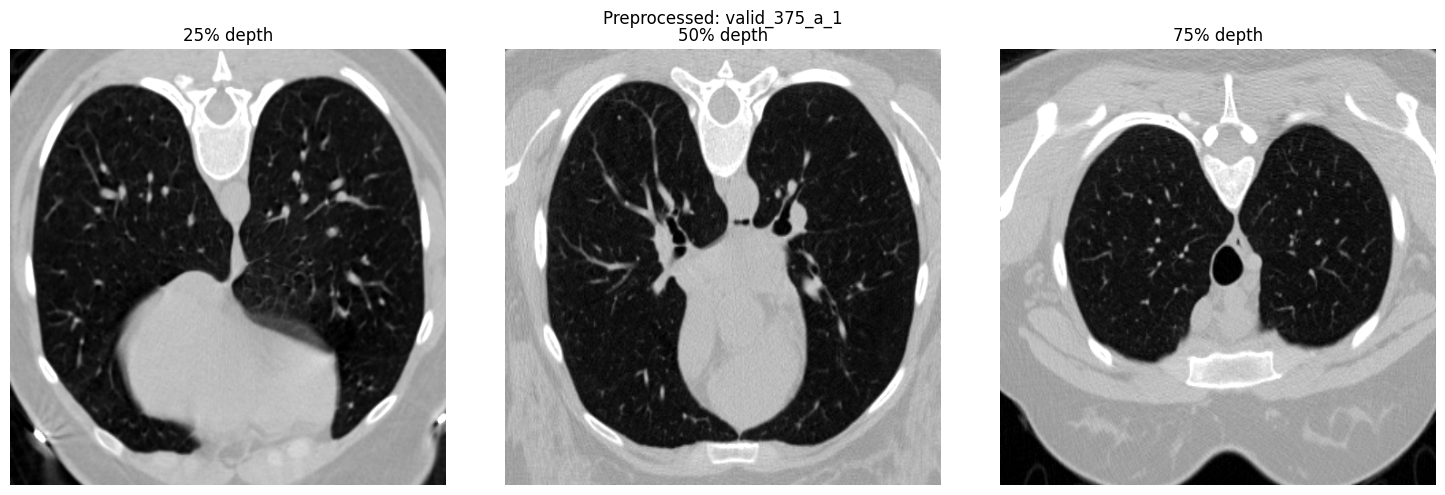

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Preprocessed: {volume_name}", fontsize=12)

for j, (ax, fraction) in enumerate(zip(axes, [0.25, 0.5, 0.75])):
    z = int(preprocessed_volume.shape[2] * fraction)
    ax.imshow(preprocessed_volume[:, :, z].T, cmap="gray", origin="lower")
    ax.set_title(f"{int(fraction*100)}% depth")
    ax.axis("off")

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "analysis/preprocessed_example.png"), dpi=150)
plt.show()

# Lung Only

In [8]:
volume_name = "valid_375_a_1"
volume_path = Path("/anvme/workspace/b180dc29-CT_RATE_IDEA_MIRROR/CT-RATE_valid_fixed/valid_375/valid_375_a/valid_375_a_1.nii.gz")
mask_dir = MASKS_ROOT / volume_name
preprocessed_path = PREPROCESSED_ROOT / f"{volume_name}.npz"

preprocess_one_volume(
    volume_path=volume_path,
    masks_dir=mask_dir,
    preprocessed_path=preprocessed_path,
    lung_only=True
)

Processing: valid_375_a_1.nii.gz
    After crop: (710, 573, 184)
    After resample: (319, 258, 184)
    After resize: (480, 480, 240)
    Saved to: /anvme/workspace/iwi5437h-ct-anomaly-detection/preprocessed_test/valid_375_a_1.npz
    Done: preprocessed shape:(480, 480, 240)


In [9]:
preprocess_result = np.load(preprocessed_path)
preprocessed_volume = preprocess_result["volume"]

print(f"Shape: {preprocessed_volume.shape}")
print(f"Dtype: {preprocessed_volume.dtype}")
print(f"Min: {preprocessed_volume.min():.4f}")
print(f"Max: {preprocessed_volume.max():.4f}")
print(f"Mean: {preprocessed_volume.mean():.4f}")

Shape: (480, 480, 240)
Dtype: float32
Min: -1.0000
Max: 0.8855
Mean: -0.9371


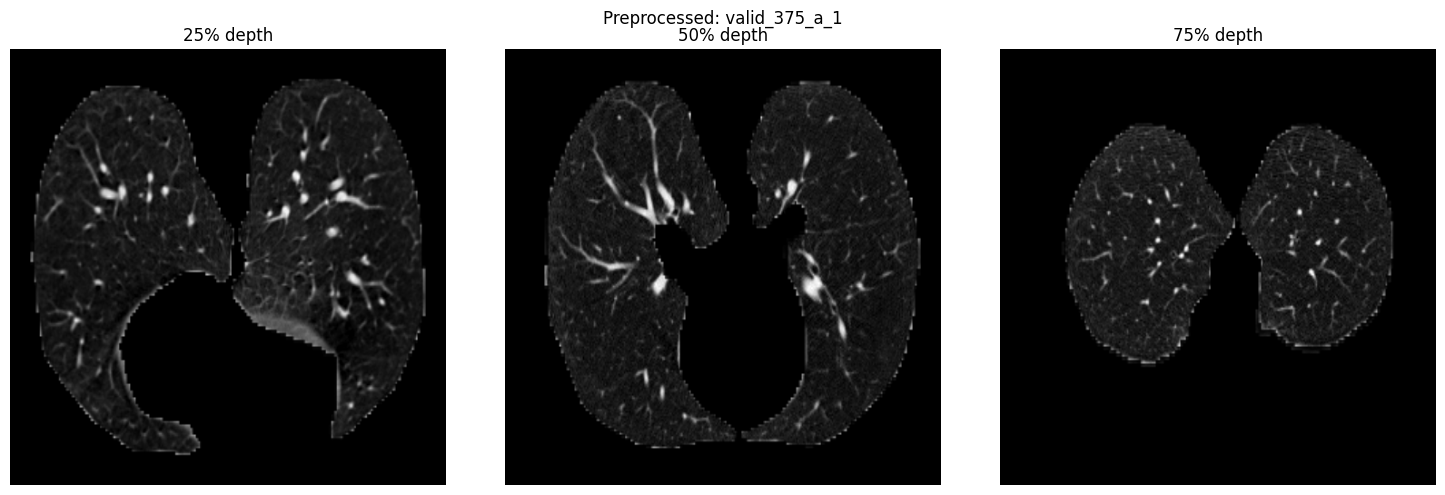

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Preprocessed: {volume_name}", fontsize=12)

for j, (ax, fraction) in enumerate(zip(axes, [0.25, 0.5, 0.75])):
    z = int(preprocessed_volume.shape[2] * fraction)
    ax.imshow(preprocessed_volume[:, :, z].T, cmap="gray", origin="lower")
    ax.set_title(f"{int(fraction*100)}% depth")
    ax.axis("off")

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "analysis/preprocessed_example_lung_only.png"), dpi=150)
plt.show()